# Mandible Segmentation — Visualization & Monitoring

Visualize data, monitor a running pipeline, and inspect results.  
Train with: `python run_pipeline.py`

In [1]:
import sys
from pathlib import Path
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
ML_DIR = Path(".").resolve()
SRC_DIR = ML_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import json
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import tifffile
import torch
from IPython.display import clear_output
from tqdm.notebook import tqdm

from config import Config
from dataset import discover_samples, LoadAndCombineMasksd
from model import build_model, load_checkpoint

import logging
logging.getLogger("monai").setLevel(logging.WARNING)

LABEL_COLORS = np.array([[0,0,0,0],[0.9,0.2,0.2,0.7],[0.2,0.4,0.9,0.7],[0.2,0.8,0.3,0.7]])
LABEL_CMAP   = ListedColormap(LABEL_COLORS)
LABEL_NAMES  = ["background", "incisor", "bone", "molar"]
LEGEND_PATCHES = [
    mpatches.Patch(color=LABEL_COLORS[i], label=LABEL_NAMES[i]) for i in range(1, 4)
]

print(f"PyTorch {torch.__version__}  |  device: {Config().resolve_device()}")

PyTorch 2.11.0+cu128  |  device: cuda


## 1 · Configuration

In [4]:
cfg = Config(
    data_dir   = "./training",
    output_dir = "./runs",
    model    = "unet",
    channels = (32, 64, 128, 256),
    dropout  = 0.2,
    max_epochs          = 300,
    batch_size          = 2,
    learning_rate       = 1e-3,
    scheduler           = "cosine",
    early_stop_patience = 50,
    patch_size          = (96, 96, 96),
    samples_per_volume  = 24,
    pos_sample_ratio    = 0.7,
    n_folds = 9,
    fold    = None,
    device  = "auto",
    sw_batch_size = 32,   # was 4  — 32 patches/pass on 32 GB GPU
    sw_overlap    = 0.25, # was 0.5 — 25x fewer forward passes during validation
)

device = cfg.resolve_device()
print(f"Device:  {device}")
print(f"Data:    {Path(cfg.data_dir).resolve()}")
print(f"Output:  {Path(cfg.output_dir).resolve()}")

Device:  cuda
Data:    C:\Users\edinh\Documents\MicroCT-Analysis\ML-Segmentation\training
Output:  C:\Users\edinh\Documents\MicroCT-Analysis\ML-Segmentation\runs


## 2 · Data Exploration

In [5]:
samples = discover_samples(cfg.data_dir)
print(f"Found {len(samples)} samples:\n")
for i, s in enumerate(samples):
    vol = tifffile.imread(s["image"])
    print(f"  [{i}] {s['name']:30s}  shape={vol.shape}  dtype={vol.dtype}  range=[{vol.min()}, {vol.max()}]")

Found 9 samples:

  [0] Cont1_5                         shape=(1428, 327, 514)  dtype=int16  range=[0, 255]
  [1] Frag_4                          shape=(1468, 425, 474)  dtype=int16  range=[0, 255]
  [2] Odam-CRE-A                      shape=(1405, 479, 839)  dtype=int16  range=[0, 248]
  [3] Odam-CRE-B                      shape=(1555, 448, 805)  dtype=int16  range=[0, 254]
  [4] Odam-CRE-C                      shape=(1337, 390, 804)  dtype=int16  range=[0, 254]
  [5] Odam-CRE-Hifla-A                shape=(1453, 456, 830)  dtype=int16  range=[0, 254]
  [6] Odam-CRE-Hifla-B                shape=(1455, 470, 802)  dtype=int16  range=[0, 248]
  [7] Odam-CRE-Hifla-C                shape=(1614, 418, 736)  dtype=int16  range=[0, 254]
  [8] P27RKO_8um_2K__reoriented       shape=(1534, 229, 656)  dtype=int16  range=[0, 159]


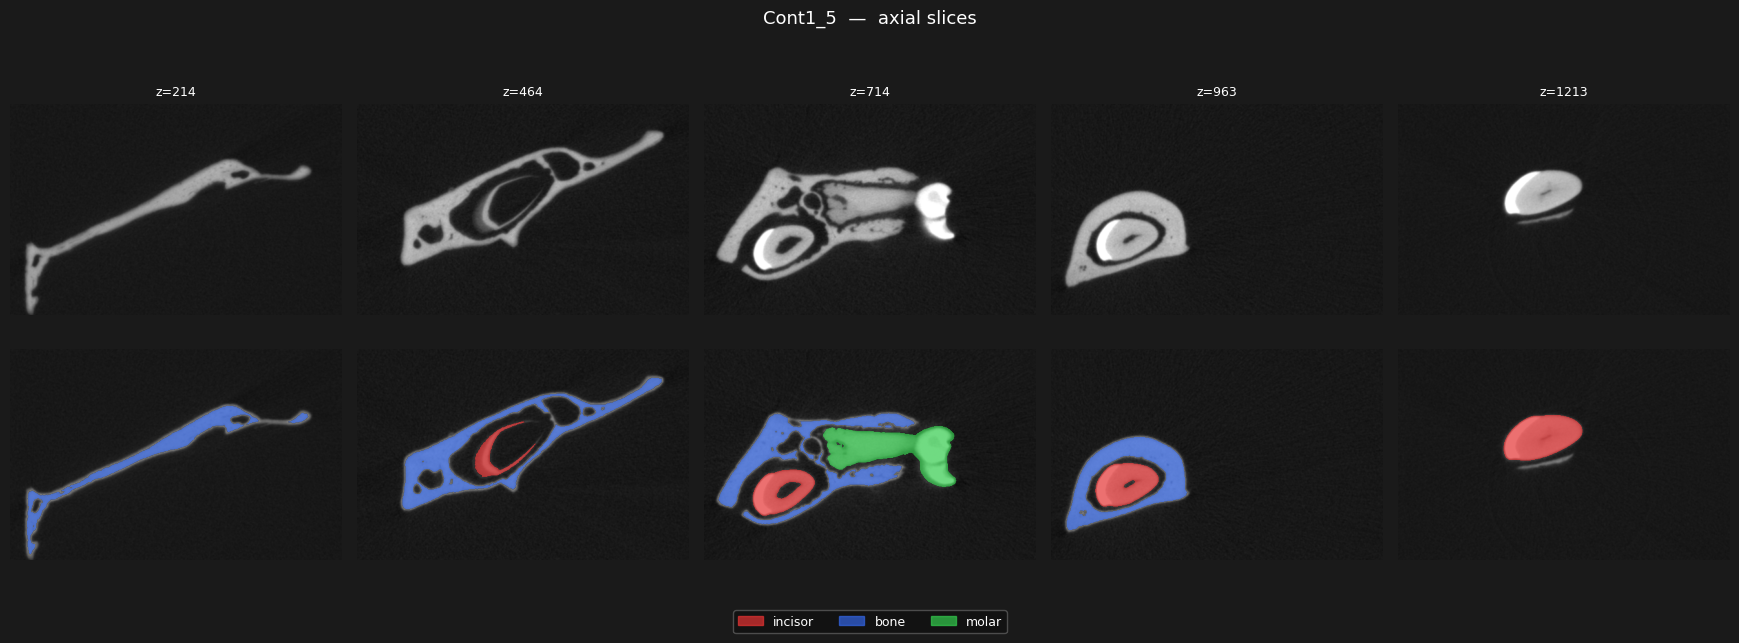

In [4]:
def show_sample_slices(sample: dict, n_slices: int = 5) -> None:
    """Display axial slices of a volume with its combined label overlay."""
    loader = LoadAndCombineMasksd()
    d     = loader(sample)
    vol   = d["image"][0]
    label = d["label"][0]
    D     = vol.shape[0]
    idxs  = np.linspace(D * 0.15, D * 0.85, n_slices, dtype=int)

    fig, axes = plt.subplots(2, n_slices, figsize=(3.5 * n_slices, 6), facecolor="#1a1a1a")
    fig.suptitle(f"{sample['name']}  —  axial slices", color="white", fontsize=13, y=1.01)

    for col, z in enumerate(idxs):
        axes[0, col].imshow(vol[z], cmap="gray", vmin=0, vmax=1)
        axes[0, col].set_title(f"z={z}", color="white", fontsize=9)
        axes[0, col].axis("off")

        axes[1, col].imshow(vol[z], cmap="gray", vmin=0, vmax=1)
        axes[1, col].imshow(label[z], cmap=LABEL_CMAP, vmin=0, vmax=3)
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("Volume", color="white", fontsize=10)
    axes[1, 0].set_ylabel("Labels", color="white", fontsize=10)
    fig.legend(handles=LEGEND_PATCHES, loc="lower center", ncol=3,
               framealpha=0.3, labelcolor="white", fontsize=9, bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()
    plt.show()


show_sample_slices(samples[0])

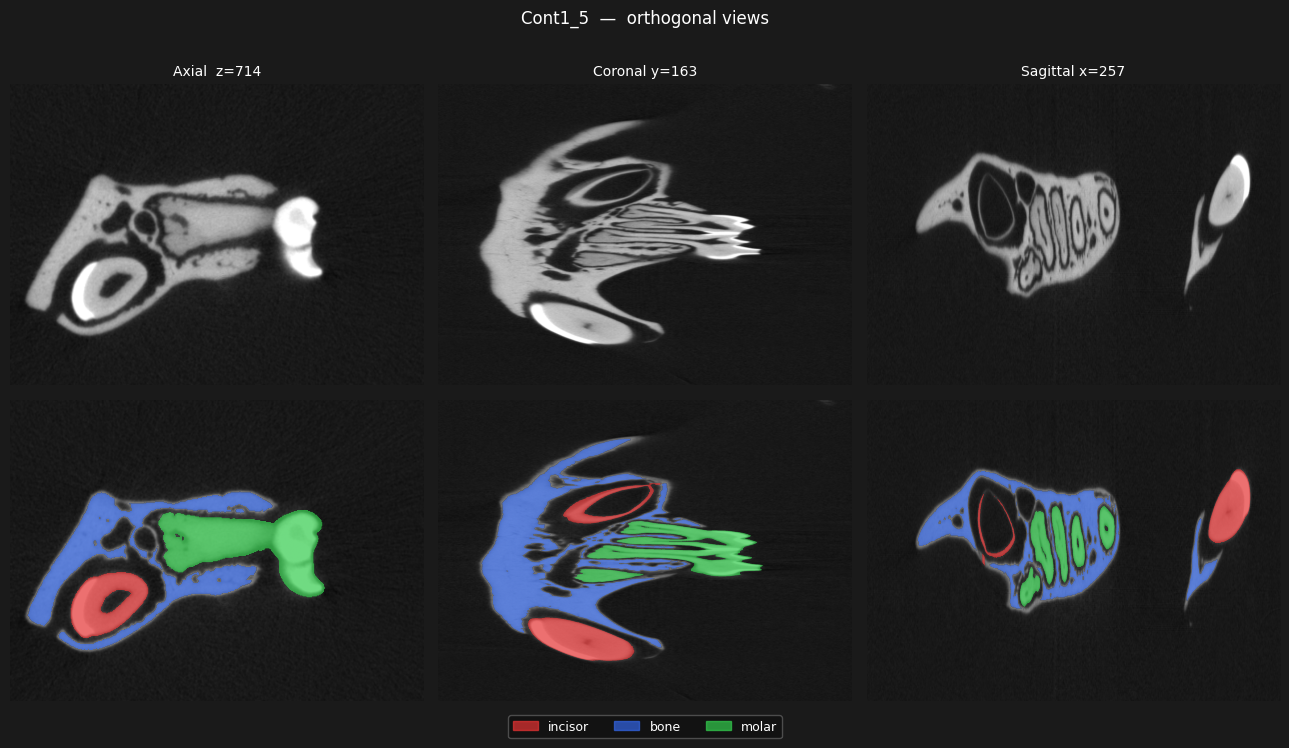

In [5]:
def show_three_views(sample: dict, z_frac=0.5, y_frac=0.5, x_frac=0.5) -> None:
    """Axial / coronal / sagittal views with label overlay."""
    loader = LoadAndCombineMasksd()
    d     = loader(sample)
    vol   = d["image"][0]
    label = d["label"][0]
    D, H, W = vol.shape
    z, y, x = int(D * z_frac), int(H * y_frac), int(W * x_frac)

    views = [
        (vol[z],         label[z],         f"Axial  z={z}"),
        (vol[:, y],      label[:, y],      f"Coronal y={y}"),
        (vol[:,:,x].T,   label[:,:,x].T,   f"Sagittal x={x}"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(13, 7), facecolor="#1a1a1a")
    fig.suptitle(f"{sample['name']}  —  orthogonal views", color="white", fontsize=12, y=1.01)

    for col, (img_s, lbl_s, title) in enumerate(views):
        axes[0, col].imshow(img_s, cmap="gray", aspect="auto", vmin=0, vmax=1)
        axes[0, col].set_title(title, color="white", fontsize=10)
        axes[0, col].axis("off")

        axes[1, col].imshow(img_s, cmap="gray", aspect="auto", vmin=0, vmax=1)
        axes[1, col].imshow(lbl_s, cmap=LABEL_CMAP, vmin=0, vmax=3, aspect="auto")
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("Volume",  color="white", fontsize=10)
    axes[1, 0].set_ylabel("Overlay", color="white", fontsize=10)
    fig.legend(handles=LEGEND_PATCHES, loc="lower center", ncol=3,
               framealpha=0.3, labelcolor="white", fontsize=9, bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()
    plt.show()


show_three_views(samples[0])

Loading masks:   0%|          | 0/9 [00:00<?, ?it/s]

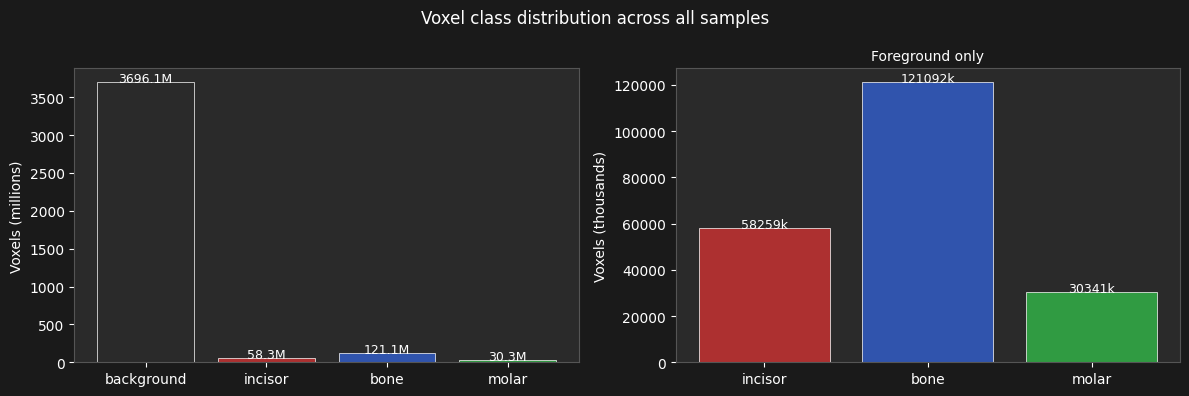


Class imbalance (bg / mean fg): 53x


In [6]:
def plot_class_distribution(samples: list) -> None:
    """Bar chart of voxel counts per class across all samples."""
    loader = LoadAndCombineMasksd()
    totals = np.zeros(4, dtype=np.int64)

    for s in tqdm(samples, desc="Loading masks"):
        d = loader(s)
        lbl = d["label"][0]
        for c in range(4):
            totals[c] += int((lbl == c).sum())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="#1a1a1a")
    fig.suptitle("Voxel class distribution across all samples", color="white", fontsize=12)
    colors = [LABEL_COLORS[i] for i in range(4)]

    ax = axes[0]
    ax.set_facecolor("#2a2a2a")
    bars = ax.bar(LABEL_NAMES, totals / 1e6, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_ylabel("Voxels (millions)", color="white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values(): spine.set_edgecolor("#555")
    for bar, v in zip(bars, totals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{v/1e6:.1f}M", ha="center", color="white", fontsize=9)

    ax2 = axes[1]
    ax2.set_facecolor("#2a2a2a")
    bars2 = ax2.bar(LABEL_NAMES[1:], totals[1:] / 1e3, color=colors[1:],
                    edgecolor="white", linewidth=0.5)
    ax2.set_ylabel("Voxels (thousands)", color="white")
    ax2.tick_params(colors="white")
    for spine in ax2.spines.values(): spine.set_edgecolor("#555")
    for bar, v in zip(bars2, totals[1:]):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{v/1e3:.0f}k", ha="center", color="white", fontsize=9)
    ax2.set_title("Foreground only", color="white", fontsize=10)

    plt.tight_layout()
    plt.show()
    print(f"\nClass imbalance (bg / mean fg): {totals[0] / totals[1:].mean():.0f}x")


plot_class_distribution(samples)

## 3 · Pipeline Monitor

In [8]:
import json, os, time
from pathlib import Path
from IPython.display import clear_output


def show_pipeline_status(runs_dir=cfg.output_dir):
    """Display the latest pipeline_status.json snapshot."""
    path = Path(runs_dir) / "pipeline_status.json"
    if not path.exists():
        print("pipeline_status.json not found.")
        print("Start training with:  python run_pipeline.py")
        return None

    with open(path) as f:
        s = json.load(f)

    status  = s.get("status", "?")
    colors  = {"running": "\033[32m", "complete": "\033[34m", "error": "\033[31m"}
    color   = colors.get(status, "")
    reset   = "\033[0m"
    updated = s.get("updated_at", "?")[:19]

    print(f"Status   : {color}{status.upper()}{reset}   (updated {updated})")
    print(f"PID      : {s.get('pid', '?')}")
    print(f"Started  : {s.get('started_at', '?')[:19]}")
    complete = s.get("folds_complete", [])
    planned  = s.get("folds_planned",  [])
    print(f"Folds    : {len(complete)}/{len(planned)} complete  {complete}")

    fold  = s.get("current_fold")
    epoch = s.get("current_epoch", 0)
    total = s.get("total_epochs", 300)
    if fold is not None:
        pct = epoch / max(total, 1) * 100
        bar = "#" * int(pct / 5) + "-" * (20 - int(pct / 5))
        print(f"Current  : Fold {fold}  Epoch {epoch}/{total}  [{bar}] {pct:.0f}%")

    pc = s.get("last_per_class", {})
    if pc:
        mean = s.get("last_val_dice") or 0
        best = s.get("best_dice_fold") or 0
        print(f"Last val : mean={mean:.4f}  "
              f"incisor={pc.get('incisor', 0):.3f}  "
              f"bone={pc.get('bone', 0):.3f}  "
              f"molar={pc.get('molar', 0):.3f}")
        print(f"Best     : {best:.4f}")

    t = s.get("timing", {})
    if t:
        el  = t.get("elapsed_total_s") or 0
        ep  = t.get("avg_epoch_s")     or 0
        eta = t.get("eta_fold_s")      or 0
        pre = t.get("preload_s")       or 0
        print(f"Timing   : total={el:.0f}s  preload={pre:.1f}s  "
              f"avg_epoch={ep:.1f}s  eta_fold={eta:.0f}s")
    return s


show_pipeline_status()

Status   : RUNNING   (updated 2026-05-08T17:04:37)
PID      : 29844
Started  : 2026-05-08T17:00:24
Folds    : 0/9 complete  []
Current  : Fold 0  Epoch 5/300  [--------------------] 2%
Last val : mean=0.0129  incisor=0.000  bone=0.000  molar=0.038
Best     : 0.0129
Timing   : total=254s  preload=72.5s  avg_epoch=31.1s  eta_fold=9187s


{'status': 'running',
 'pid': 29844,
 'started_at': '2026-05-08T17:00:24.092405',
 'folds_planned': [0, 1, 2, 3, 4, 5, 6, 7, 8],
 'folds_complete': [],
 'folds_skipped': [],
 'current_fold': 0,
 'current_epoch': 5,
 'total_epochs': 300,
 'timing': {'preload_s': 72.5,
  'fold_elapsed_s': 155.7,
  'avg_epoch_s': 31.14,
  'eta_fold_s': 9187.0,
  'elapsed_total_s': 253.8},
 'best_dice_fold': 0.0129,
 'last_val_dice': 0.0129,
 'last_per_class': {'incisor': 0.0003, 'bone': 0.0, 'molar': 0.0384},
 'updated_at': '2026-05-08T17:04:37.943374'}

Status   : RUNNING   (updated 2026-05-08T17:28:09)
PID      : 29844
Started  : 2026-05-08T17:00:24
Folds    : 0/9 complete  []
Current  : Fold 0  Epoch 60/300  [####----------------] 20%
Last val : mean=0.0180  incisor=0.000  bone=0.006  molar=0.048
Best     : 0.0180
Timing   : total=1666s  preload=72.5s  avg_epoch=26.1s  eta_fold=6271s


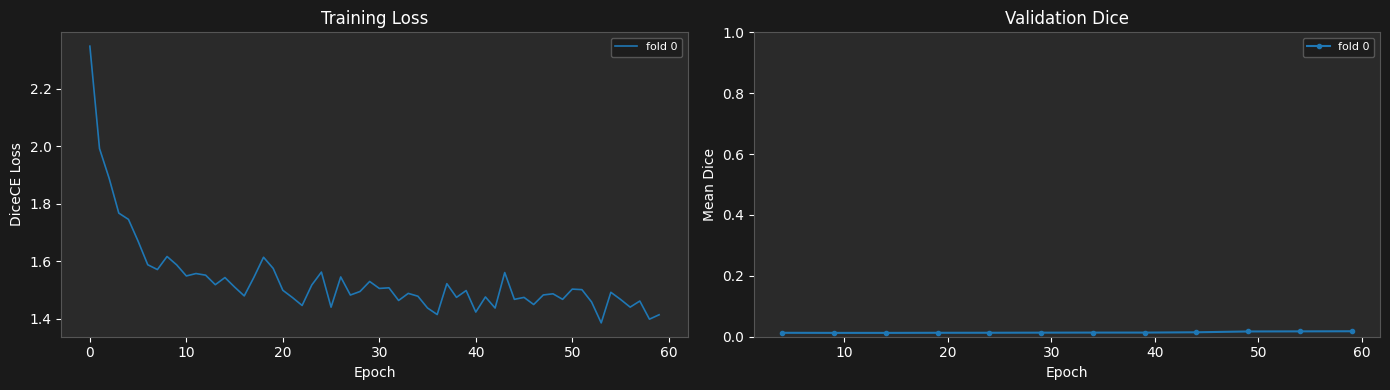


Poll 4/200  —  refreshing in 300s  (Ctrl+C to stop)


In [ ]:
def monitor_pipeline(runs_dir=cfg.output_dir, interval_s=30, max_polls=200):
    """
    Poll pipeline_status.json + history.json and refresh plots.
    Runs until pipeline completes or max_polls is reached.
    Ctrl+C to stop early.
    """
    runs_dir = Path(runs_dir)

    for poll in range(max_polls):
        clear_output(wait=True)
        s = show_pipeline_status(runs_dir)

        fold_histories = {}
        for fold_dir in sorted(runs_dir.glob("fold_*")):
            hp = fold_dir / "history.json"
            if hp.exists():
                with open(hp) as f:
                    data = json.load(f)
                fi = int(fold_dir.name.split("_")[1])
                fold_histories[fi] = data

        if fold_histories:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), facecolor="#1a1a1a")
            cmap = plt.cm.tab10

            for i, (fi, h) in enumerate(sorted(fold_histories.items())):
                col      = cmap(i / max(len(fold_histories), 1))
                eps      = h.get("epochs",     [])
                loss     = h.get("train_loss", [])
                vd       = h.get("val_dice",   [])
                pc_all   = h.get("per_class",  [])
                if eps and loss:
                    ax1.plot(eps, loss, color=col, lw=1.2, label=f"fold {fi}")
                val_ep   = [e for e, d in zip(eps, vd) if d > 0]
                val_dice = [d for d in vd if d > 0]
                if val_ep:
                    ax2.plot(val_ep, val_dice, color=col, lw=1.5,
                             marker="o", ms=3, label=f"fold {fi}")

            for ax, title, ylabel in [
                (ax1, "Training Loss",    "DiceCE Loss"),
                (ax2, "Validation Dice",  "Mean Dice"),
            ]:
                ax.set_facecolor("#2a2a2a")
                ax.tick_params(colors="white")
                for sp in ax.spines.values():
                    sp.set_edgecolor("#555")
                ax.set_title(title,  color="white")
                ax.set_xlabel("Epoch", color="white")
                ax.set_ylabel(ylabel,  color="white")
                ax.legend(framealpha=0.3, labelcolor="white", fontsize=8, ncol=2)

            ax2.set_ylim(0, 1)
            plt.tight_layout()
            plt.show()

        if s and s.get("status") in ("complete", "error"):
            print(f"\nPipeline {s['status']}. Monitor stopping.")
            break

        print(f"\nPoll {poll + 1}/{max_polls}  —  refreshing in {interval_s}s  (Ctrl+C to stop)")
        time.sleep(interval_s)


# Uncomment to start live monitoring (refreshes every 30 s):
monitor_pipeline(interval_s=300)

In [10]:
class FoldHistory:
    """Accumulates per-epoch metrics and provides per-fold loss/Dice plotting."""

    def __init__(self, fold_idx: int):
        self.fold_idx   = fold_idx
        self.epochs     = []
        self.train_loss = []
        self.val_dice   = []
        self.per_class  = []
        self.lr         = []

    def update(self, epoch, loss, dice, per_class, lr):
        self.epochs.append(epoch)
        self.train_loss.append(loss)
        self.val_dice.append(dice)
        self.per_class.append(per_class)
        self.lr.append(lr)

    def plot(self, show=True):
        fig, (ax_loss, ax_dice) = plt.subplots(1, 2, figsize=(12, 4), facecolor="#1a1a1a")

        for ax in (ax_loss, ax_dice):
            ax.set_facecolor("#2a2a2a")
            ax.tick_params(colors="white")
            for spine in ax.spines.values():
                spine.set_edgecolor("#555")

        ax_loss.plot(self.epochs, self.train_loss, color="#f0a500", lw=1.5, label="train loss")
        ax_loss.set_title(f"Fold {self.fold_idx} — Training Loss", color="white", fontsize=11)
        ax_loss.set_xlabel("Epoch", color="white")
        ax_loss.set_ylabel("DiceCE Loss", color="white")
        ax_loss.legend(framealpha=0.3, labelcolor="white")

        val_ep   = [e for e, d in zip(self.epochs, self.val_dice) if d > 0]
        val_dice = [d for d in self.val_dice if d > 0]
        if val_ep:
            ax_dice.plot(val_ep, val_dice, color="#00d4aa", lw=2, marker="o", ms=4,
                         label="mean Dice")
            pc = np.array([p for p, d in zip(self.per_class, self.val_dice) if d > 0])
            if pc.ndim == 2 and pc.shape[1] >= 3:
                for i, (name, col) in enumerate(zip(
                    ["incisor", "bone", "molar"], ["#ff6b6b", "#4da6ff", "#69db7c"]
                )):
                    ax_dice.plot(val_ep, pc[:, i], lw=1.2, ls="--", color=col, label=name)

        ax_dice.set_title(f"Fold {self.fold_idx} — Validation Dice", color="white", fontsize=11)
        ax_dice.set_xlabel("Epoch", color="white")
        ax_dice.set_ylabel("Dice", color="white")
        ax_dice.set_ylim(0, 1)
        ax_dice.legend(framealpha=0.3, labelcolor="white", fontsize=8)

        if show:
            plt.tight_layout()
            plt.show()


print("FoldHistory ready.")

FoldHistory ready.


## 4 · Cross-Validation Summary

In [ ]:
def plot_cv_summary(all_histories: dict) -> None:
    folds      = sorted(all_histories.keys())
    best_dices = []
    per_class  = []

    for f in folds:
        h  = all_histories[f]
        bd = max((d for d in h.val_dice if d > 0), default=0.0)
        best_dices.append(bd)
        idx = h.val_dice.index(bd) if bd in h.val_dice else 0
        per_class.append(h.per_class[idx])

    pc_arr = np.array(per_class)
    fig    = plt.figure(figsize=(14, 5), facecolor="#1a1a1a")
    gs     = gridspec.GridSpec(1, 2, width_ratios=[1, 2])

    ax1 = fig.add_subplot(gs[0])
    ax1.set_facecolor("#2a2a2a")
    ax1.tick_params(colors="white")
    for spine in ax1.spines.values(): spine.set_edgecolor("#555")
    fold_labels = [f"fold {f}" for f in folds]
    bars = ax1.barh(fold_labels, best_dices, color="#00d4aa", edgecolor="white", linewidth=0.5)
    ax1.axvline(np.mean(best_dices), color="#f0a500", lw=1.5, ls="--",
                label=f"mean={np.mean(best_dices):.3f}")
    ax1.set_xlim(0, 1)
    ax1.set_title("Best mean Dice per fold", color="white", fontsize=11)
    ax1.set_xlabel("Dice", color="white")
    ax1.legend(framealpha=0.3, labelcolor="white", fontsize=9)
    for bar, v in zip(bars, best_dices):
        ax1.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{v:.3f}", va="center", color="white", fontsize=9)

    ax2 = fig.add_subplot(gs[1])
    ax2.set_facecolor("#2a2a2a")
    ax2.tick_params(colors="white")
    for spine in ax2.spines.values(): spine.set_edgecolor("#555")
    x, width = np.arange(len(folds)), 0.25
    for i, (name, col) in enumerate(zip(
            ["incisor", "bone", "molar"], ["#ff6b6b", "#4da6ff", "#69db7c"])):
        ax2.bar(x + i * width, pc_arr[:, i], width, label=name,
                color=col, edgecolor="white", linewidth=0.5)
    ax2.set_xticks(x + width)
    ax2.set_xticklabels(fold_labels, color="white", rotation=30, ha="right")
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("Dice", color="white")
    ax2.set_title("Per-class Dice per fold", color="white", fontsize=11)
    ax2.legend(framealpha=0.3, labelcolor="white", fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"\n{'Fold':<8} {'Mean':>6} {'Incisor':>9} {'Bone':>6} {'Molar':>7}")
    print("-" * 42)
    for f, bd, pc in zip(folds, best_dices, per_class):
        print(f"  {f:<6} {bd:>6.3f}  {pc[0]:>7.3f}  {pc[1]:>6.3f}  {pc[2]:>7.3f}")
    print("-" * 42)
    print(f"  {'mean':<6} {np.mean(best_dices):>6.3f}  "
          f"{np.nanmean(pc_arr[:,0]):>7.3f}  "
          f"{np.nanmean(pc_arr[:,1]):>6.3f}  "
          f"{np.nanmean(pc_arr[:,2]):>7.3f}")
    print(f"  {'std':<6} {np.std(best_dices):>6.3f}  "
          f"{np.nanstd(pc_arr[:,0]):>7.3f}  "
          f"{np.nanstd(pc_arr[:,1]):>6.3f}  "
          f"{np.nanstd(pc_arr[:,2]):>7.3f}")


def plot_all_loss_curves(all_histories: dict) -> None:
    fig, (ax_loss, ax_dice) = plt.subplots(1, 2, figsize=(13, 4), facecolor="#1a1a1a")
    cmap = plt.cm.tab10

    for i, (fold_idx, h) in enumerate(sorted(all_histories.items())):
        col = cmap(i / max(len(all_histories), 1))
        ax_loss.plot(h.epochs, h.train_loss, color=col, lw=1.2, label=f"fold {fold_idx}")
        val_ep   = [e for e, d in zip(h.epochs, h.val_dice) if d > 0]
        val_dice = [d for d in h.val_dice if d > 0]
        if val_ep:
            ax_dice.plot(val_ep, val_dice, color=col, lw=1.5, marker="o", ms=3,
                         label=f"fold {fold_idx}")

    for ax, title, ylabel in [
        (ax_loss, "Training Loss — all folds", "DiceCE Loss"),
        (ax_dice, "Validation Dice — all folds", "Mean Dice"),
    ]:
        ax.set_facecolor("#2a2a2a")
        ax.tick_params(colors="white")
        for spine in ax.spines.values(): spine.set_edgecolor("#555")
        ax.set_title(title, color="white", fontsize=11)
        ax.set_xlabel("Epoch", color="white")
        ax.set_ylabel(ylabel, color="white")
        ax.legend(framealpha=0.3, labelcolor="white", fontsize=8, ncol=2)

    ax_dice.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()


if all_histories:
    plot_cv_summary(all_histories)
    plot_all_loss_curves(all_histories)

## 5 · Load Saved Results

Reload histories from disk after training has already run, without re-running any cells above.

In [ ]:
def load_histories_from_disk(runs_dir) -> dict:
    """Reconstruct FoldHistory objects from saved history.json files."""
    histories = {}
    for fold_dir in sorted(Path(runs_dir).glob("fold_*")):
        hist_path = fold_dir / "history.json"
        if not hist_path.exists():
            continue
        with open(hist_path) as fh:
            data = json.load(fh)
        fold_idx   = int(fold_dir.name.split("_")[1])
        h          = FoldHistory(fold_idx)
        epochs     = data.get("epochs",     data.get("epoch", []))
        train_loss = data.get("train_loss", [])
        val_dice   = data.get("val_dice",   [])
        per_class  = data.get("per_class",  data.get("per_class_dice", []))
        for ep, lo, vd, pc in zip(epochs, train_loss, val_dice, per_class):
            h.update(ep, lo, vd, pc, lr=0.0)
        histories[fold_idx] = h
        print(f"Loaded fold {fold_idx}: {len(epochs)} epochs")
    return histories


# Uncomment to reload from disk:
# all_histories = load_histories_from_disk(cfg.output_dir)
# plot_cv_summary(all_histories)
print("load_histories_from_disk() ready.")

## 6 · Prediction Visualization

In [ ]:
from predict import predict_volume


def visualize_prediction(sample: dict, checkpoint_path, cfg: Config, n_slices: int = 5) -> None:
    """
    Run inference on a sample and show:
      Row 1: raw volume
      Row 2: ground-truth overlay
      Row 3: prediction overlay
      Row 4: error map  (FP=orange, FN=purple)
    """
    device = cfg.resolve_device()
    loader = LoadAndCombineMasksd()
    d      = loader(sample)
    vol    = d["image"][0]
    label  = d["label"][0]

    model = build_model(
        model_name=cfg.model, in_channels=cfg.in_channels,
        num_classes=cfg.num_classes, channels=cfg.channels,
        strides=cfg.strides, dropout=cfg.dropout,
    ).to(device)
    load_checkpoint(model, str(checkpoint_path), device=device)

    raw_vol = tifffile.imread(sample["image"])
    pred_label, _ = predict_volume(model, raw_vol, cfg, device)

    gt_fg   = (label > 0).astype(np.uint8)
    pred_fg = (pred_label > 0).astype(np.uint8)
    error   = np.zeros_like(label, dtype=np.uint8)
    error[(pred_fg == 1) & (gt_fg == 0)] = 1
    error[(pred_fg == 0) & (gt_fg == 1)] = 2
    error_cmap = ListedColormap([[0,0,0,0],[1,0.5,0,0.8],[0.6,0,0.8,0.8]])

    D    = vol.shape[0]
    idxs = np.linspace(D * 0.15, D * 0.85, n_slices, dtype=int)

    row_labels = ["Volume", "Ground truth", "Prediction", "Errors"]
    fig, axes  = plt.subplots(4, n_slices, figsize=(3.5 * n_slices, 2.8 * 4), facecolor="#1a1a1a")
    fig.suptitle(f"{sample['name']}  —  prediction vs ground truth",
                 color="white", fontsize=13, y=1.01)

    overlays = [(None, None, None), (label, LABEL_CMAP, 3),
                (pred_label, LABEL_CMAP, 3), (error, error_cmap, 2)]

    for col, z in enumerate(idxs):
        for row, (ov_arr, ov_cmap, ov_vmax) in enumerate(overlays):
            ax = axes[row, col]
            ax.imshow(vol[z], cmap="gray", vmin=0, vmax=1)
            if ov_arr is not None:
                ax.imshow(ov_arr[z], cmap=ov_cmap, vmin=0, vmax=ov_vmax)
            ax.axis("off")
            if row == 0:
                ax.set_title(f"z={z}", color="white", fontsize=9)

    for row, rl in enumerate(row_labels):
        axes[row, 0].set_ylabel(rl, color="white", fontsize=9)

    err_patches = [
        mpatches.Patch(color=[1,0.5,0,0.8],   label="FP (over)"),
        mpatches.Patch(color=[0.6,0,0.8,0.8], label="FN (under)"),
    ]
    fig.legend(handles=LEGEND_PATCHES + err_patches,
               loc="lower center", ncol=5, framealpha=0.3,
               labelcolor="white", fontsize=9, bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()
    plt.show()

    print(f"\n{sample['name']} — per-class Dice:")
    for c, name in enumerate(["incisor", "bone", "molar"], start=1):
        gt_m   = (label == c)
        pr_m   = (pred_label == c)
        inter  = (gt_m & pr_m).sum()
        denom  = gt_m.sum() + pr_m.sum()
        dice_v = 2 * inter / denom if denom > 0 else float("nan")
        print(f"  {name:<10}: {dice_v:.4f}  (GT={gt_m.sum():,}  pred={pr_m.sum():,})")


CHECKPOINT = Path(cfg.output_dir) / "fold_0" / "best_model.pt"
VAL_SAMPLE = samples[0]

if CHECKPOINT.exists():
    visualize_prediction(VAL_SAMPLE, CHECKPOINT, cfg)
else:
    print(f"Checkpoint not found: {CHECKPOINT}\nRun training first (Section 3).")

In [ ]:
def plot_probability_maps(sample: dict, checkpoint_path, cfg: Config, z_frac: float = 0.5) -> None:
    """Show raw softmax probability maps per class at one axial slice."""
    device = cfg.resolve_device()
    model  = build_model(
        model_name=cfg.model, in_channels=cfg.in_channels,
        num_classes=cfg.num_classes, channels=cfg.channels,
        strides=cfg.strides, dropout=cfg.dropout,
    ).to(device)
    load_checkpoint(model, str(checkpoint_path), device=device)

    raw_vol = tifffile.imread(sample["image"])
    _, probs = predict_volume(model, raw_vol, cfg, device)   # (C, D, H, W)

    loader = LoadAndCombineMasksd()
    d   = loader(sample)
    vol = d["image"][0]
    z   = int(vol.shape[0] * z_frac)

    n_cols = cfg.num_classes + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4), facecolor="#1a1a1a")
    fig.suptitle(f"{sample['name']}  —  softmax probabilities  (z={z})",
                 color="white", fontsize=12)

    axes[0].imshow(vol[z], cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Volume", color="white", fontsize=10)
    axes[0].axis("off")

    for c, name in enumerate(LABEL_NAMES):
        ax   = axes[c + 1]
        prob = probs[c, z]
        im   = ax.imshow(prob, cmap="inferno", vmin=0, vmax=1)
        ax.set_title(f"{name}\nmax={prob.max():.3f}", color="white", fontsize=9)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


if CHECKPOINT.exists():
    plot_probability_maps(VAL_SAMPLE, CHECKPOINT, cfg, z_frac=0.5)
else:
    print("Run training first.")

## 7 · Staged Prediction Assessment

Compares three decoding strategies on the **same** softmax probability output:

| Strategy | Logic |
|---|---|
| **Flat argmax** | `argmax` over all 4 channels — current default |
| **Staged (bg gate)** | Background hard-vetoed where `bg_prob ≥ bg_threshold`; foreground classes share the remaining probability budget |
| **Staged (bg + bone gate)** | Background vetoed → bone assigned first where `bone_prob ≥ bone_threshold` → incisor vs molar by binary argmax on just those two channels |

**Run in order:** cells 7.1 → 7.2 (computes `probs` once) → 7.3 → 7.4 → 7.5 → 7.6.  
After the threshold sweep (7.5) update `BG_THRESHOLD` / `BONE_THRESHOLD` in 7.3 and re-run.  
After finding the best settings on one fold, run 7.6 to assess across all folds.

In [3]:
from predict import _staged_from_probs, predict_volume as _predict_vol_staged


def per_class_dice(pred: np.ndarray, gt: np.ndarray) -> dict:
    """Dice for incisor (1), bone (2), molar (3) between two integer label maps."""
    out = {}
    for c, name in zip([1, 2, 3], ["incisor", "bone", "molar"]):
        gt_m  = (gt   == c)
        pr_m  = (pred == c)
        inter = int((gt_m & pr_m).sum())
        denom = int(gt_m.sum() + pr_m.sum())
        out[name] = 2 * inter / denom if denom > 0 else float("nan")
    return out


print("Staged helpers loaded.")

Staged helpers loaded.


In [7]:
# ── Load checkpoint and compute softmax probabilities (run once per fold) ─────
# fold N uses samples[N] as its validation sample (leave-one-out)
EVAL_FOLD = 0

_ckpt = Path(cfg.output_dir) / f"fold_{EVAL_FOLD}" / "best_model.pt"
_samp = samples[EVAL_FOLD]

if not _ckpt.exists():
    print(f"No checkpoint: {_ckpt}\nRun training first (Section 3).")
else:
    _model = build_model(
        model_name=cfg.model, in_channels=cfg.in_channels,
        num_classes=cfg.num_classes, channels=cfg.channels,
        strides=cfg.strides, dropout=cfg.dropout,
    ).to(device)
    load_checkpoint(_model, str(_ckpt), device=device)

    _loader = LoadAndCombineMasksd()
    _d      = _loader(_samp)
    _vol_f  = _d["image"][0]   # (D, H, W) float32 — used for display
    _gt     = _d["label"][0]   # (D, H, W) uint8   — ground truth

    _raw    = tifffile.imread(_samp["image"])
    _, probs = _predict_vol_staged(_model, _raw, cfg, device)

    print(f"Fold {EVAL_FOLD}  |  val = {_samp['name']}  |  probs {probs.shape}")
    print(f"\nBackground prob distribution across all voxels:")
    print(f"  min={probs[0].min():.4f}  median={np.median(probs[0]):.4f}  max={probs[0].max():.4f}")
    print(f"  p5={np.percentile(probs[0], 5):.4f}  p95={np.percentile(probs[0], 95):.4f}")
    _fg_pct = 100 * (probs[0] < 0.05).mean()
    print(f"  Voxels passing bg<0.05 gate: {(probs[0]<0.05).sum():,}  ({_fg_pct:.1f}% of volume)")

[INFO] 15:33:40    [Cont1_5             ]  imread image   2.3s  shape=(1428, 327, 514)  960 MB
[INFO] 15:33:51    [Cont1_5             ]  imread masks   3.1s
[INFO] 15:33:51    [Cont1_5             ]  load+combine   13.8s total


Fold 0  |  val = Cont1_5  |  probs (4, 1428, 327, 514)

Background prob distribution across all voxels:
  min=0.0000  median=0.8721  max=1.0000
  p5=0.0032  p95=0.9853
  Voxels passing bg<0.05 gate: 18,152,863  (7.6% of volume)


In [11]:
# ── Method comparison — edit thresholds after seeing the sweep below ──────────
BG_THRESHOLD   = 0.05
BONE_THRESHOLD = 0.25    # set to None to skip the bone gate

flat_map  = probs.argmax(axis=0).astype(np.int32)
staged_bg = _staged_from_probs(probs, bg_threshold=BG_THRESHOLD, bone_threshold=None)
staged_b2 = _staged_from_probs(probs, bg_threshold=BG_THRESHOLD, bone_threshold=BONE_THRESHOLD)

_methods = {
    "flat argmax":                                          flat_map,
    f"staged  bg<{BG_THRESHOLD}":                          staged_bg,
    f"staged  bg<{BG_THRESHOLD}  bone≥{BONE_THRESHOLD}":   staged_b2,
}

_results = {n: per_class_dice(p, _gt) for n, p in _methods.items()}
_best_mean = max(np.nanmean(list(d.values())) for d in _results.values())

print(f"{'Method':<46} {'incisor':>9} {'bone':>8} {'molar':>8} {'mean':>8}")
print("─" * 83)
for _mname, _dc in _results.items():
    _mn   = np.nanmean(list(_dc.values()))
    _mark = "  ◀ best" if _mn == _best_mean else ""
    print(f"  {_mname:<44}  {_dc['incisor']:>9.4f} {_dc['bone']:>8.4f} {_dc['molar']:>8.4f} {_mn:>8.4f}{_mark}")

Method                                           incisor     bone    molar     mean
───────────────────────────────────────────────────────────────────────────────────
  flat argmax                                      0.8037   0.7397   0.3845   0.6426
  staged  bg<0.05                                  0.8803   0.7572   0.4315   0.6896
  staged  bg<0.05  bone≥0.25                       0.8804   0.8103   0.4929   0.7279  ◀ best


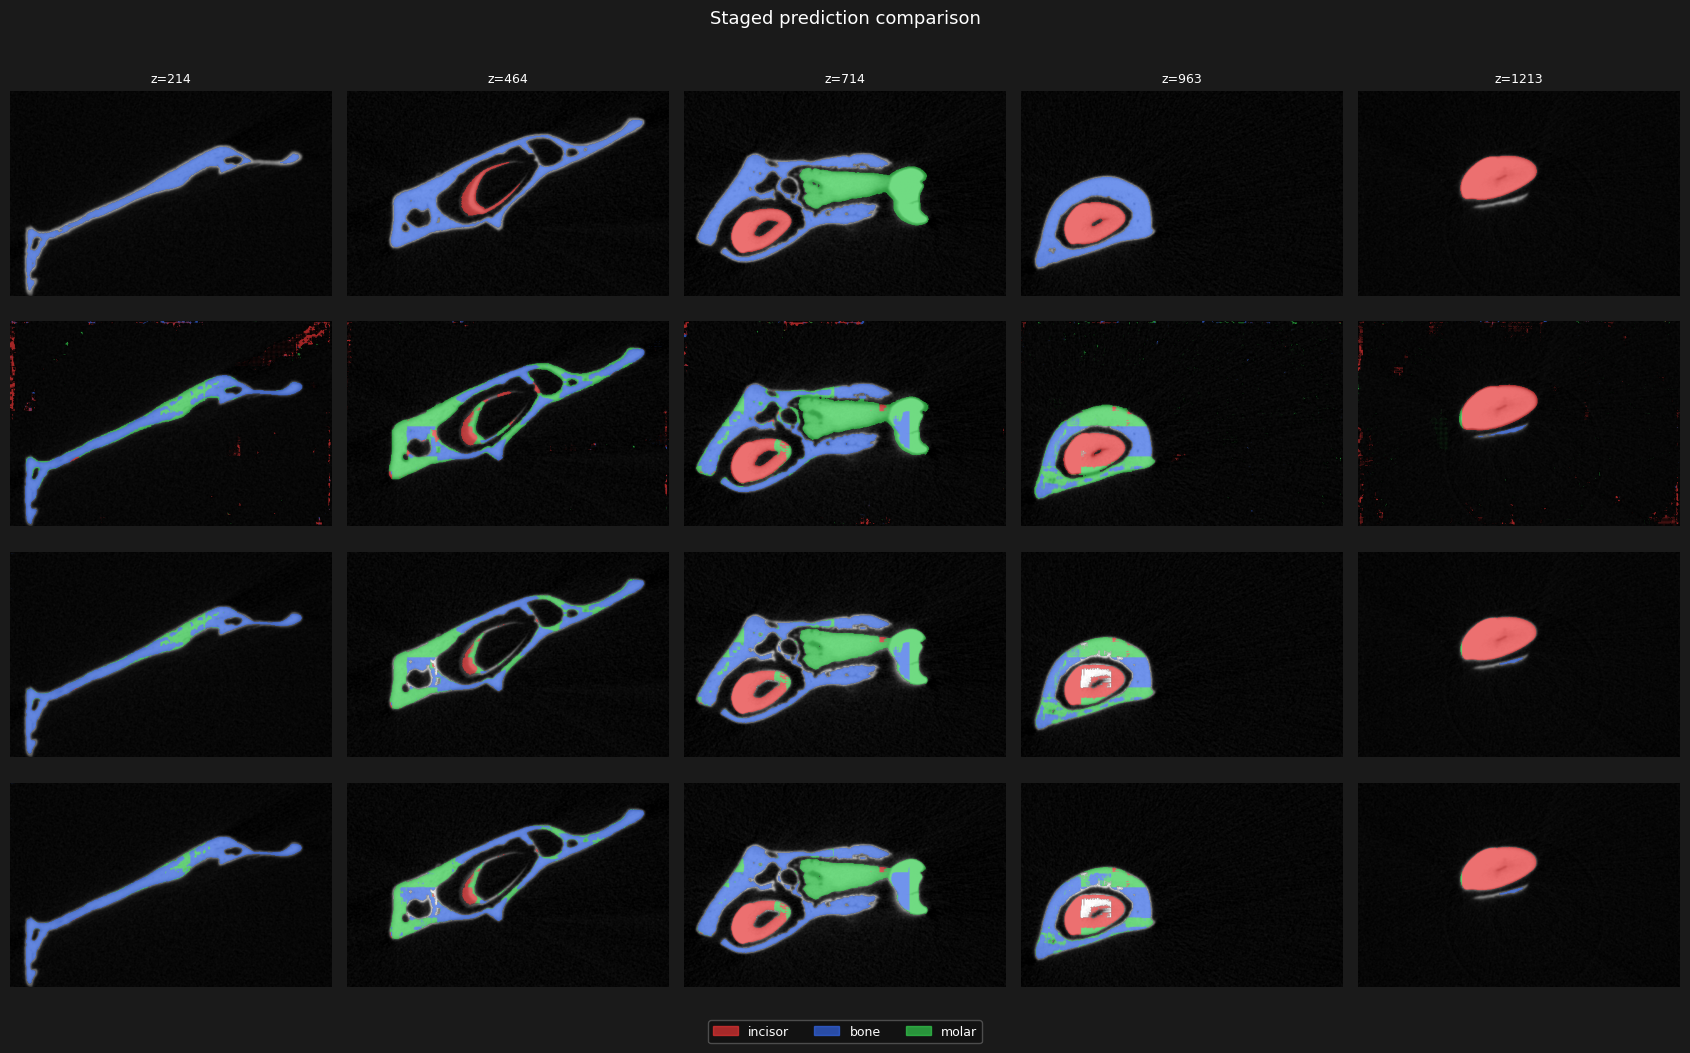

In [12]:
# ── Visual comparison: GT / flat / staged-bg / staged-bg+bone ─────────────────
def compare_staged_slices(vol, gt, pred_dict, n_slices=5):
    D    = vol.shape[0]
    idxs = np.linspace(D * 0.15, D * 0.85, n_slices, dtype=int)
    rows = [("Ground truth", gt)] + list(pred_dict.items())

    fig, axes = plt.subplots(
        len(rows), n_slices,
        figsize=(3.4 * n_slices, 2.5 * len(rows)),
        facecolor="#1a1a1a",
    )
    fig.suptitle("Staged prediction comparison", color="white", fontsize=13, y=1.01)

    for col, z in enumerate(idxs):
        axes[0, col].set_title(f"z={z}", color="white", fontsize=9)
        for row, (label, lmap) in enumerate(rows):
            ax = axes[row, col]
            ax.imshow(vol[z], cmap="gray", vmin=0, vmax=1)
            ax.imshow(lmap[z], cmap=LABEL_CMAP, vmin=0, vmax=3)
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(label, color="white", fontsize=8)

    fig.legend(handles=LEGEND_PATCHES, loc="lower center", ncol=3,
               framealpha=0.3, labelcolor="white", fontsize=9, bbox_to_anchor=(0.5, -0.03))
    plt.tight_layout()
    plt.show()


compare_staged_slices(_vol_f, _gt, _methods)

In [10]:
# ── Threshold sweep: Dice vs bg_threshold × bone_threshold ───────────────────
_bg_vals   = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
_bone_vals = [None, 0.3, 0.4, 0.5, 0.6, 0.7]

_sweep = {
    (_bg, _bn): per_class_dice(_staged_from_probs(probs, _bg, _bn), _gt)
    for _bg in _bg_vals for _bn in _bone_vals
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor="#1a1a1a")
_colors    = plt.cm.plasma(np.linspace(0.1, 0.9, len(_bone_vals)))

for ax, cname in zip(axes, ["incisor", "bone", "molar"]):
    ax.set_facecolor("#2a2a2a")
    ax.tick_params(colors="white")
    for sp in ax.spines.values():
        sp.set_edgecolor("#555")

    for _bn, _col in zip(_bone_vals, _colors):
        _ys  = [_sweep[(_bg, _bn)][cname] for _bg in _bg_vals]
        _lbl = f"bone≥{_bn}" if _bn is not None else "no bone gate"
        ax.plot(_bg_vals, _ys, marker="o", ms=5, lw=1.5, color=_col, label=_lbl)

    _flat_d = per_class_dice(flat_map, _gt)[cname]
    ax.axhline(_flat_d, ls="--", lw=1.2, color="white", alpha=0.6,
               label=f"flat={_flat_d:.3f}")
    ax.set_title(cname, color="white", fontsize=11)
    ax.set_xlabel("bg_threshold", color="white")
    ax.set_ylabel("Dice", color="white")
    _all_vals = [_sweep[k][cname] for k in _sweep] + [_flat_d]
    ax.set_ylim(max(0, min(_all_vals) - 0.02), 1)
    ax.legend(framealpha=0.3, labelcolor="white", fontsize=7)

plt.suptitle(f"Threshold sweep — fold {EVAL_FOLD}: {_samp['name']}",
             color="white", fontsize=12)
plt.tight_layout()
plt.show()

# Best threshold combo per class
print("Best thresholds found:")
for cname in ["incisor", "bone", "molar"]:
    _best  = max(_sweep, key=lambda k: _sweep[k][cname])
    _flat_d = per_class_dice(flat_map, _gt)[cname]
    print(f"  {cname:>8}:  bg<{_best[0]}  bone≥{_best[1]}"
          f"  →  Dice={_sweep[_best][cname]:.4f}"
          f"  (flat={_flat_d:.4f}  Δ={_sweep[_best][cname]-_flat_d:+.4f})")

KeyboardInterrupt: 

In [ ]:
# ── CV-wide assessment: every fold's val sample ───────────────────────────────
# Update these to match the best combo found in the sweep above
BEST_BG_THRESHOLD   = 0.05
BEST_BONE_THRESHOLD = 0.5

_cv_rows = []
for _fi in range(len(samples)):
    _ck = Path(cfg.output_dir) / f"fold_{_fi}" / "best_model.pt"
    if not _ck.exists():
        print(f"  fold {_fi}: no checkpoint, skipping"); continue

    _m = build_model(
        model_name=cfg.model, in_channels=cfg.in_channels,
        num_classes=cfg.num_classes, channels=cfg.channels,
        strides=cfg.strides, dropout=cfg.dropout,
    ).to(device)
    load_checkpoint(_m, str(_ck), device=device)

    _s  = samples[_fi]
    _dd = LoadAndCombineMasksd()(_s)
    _g  = _dd["label"][0]
    _rv = tifffile.imread(_s["image"])
    _, _pr = _predict_vol_staged(_m, _rv, cfg, device)

    _flat_dc   = per_class_dice(_pr.argmax(axis=0).astype(np.int32), _g)
    _staged_dc = per_class_dice(
        _staged_from_probs(_pr, BEST_BG_THRESHOLD, BEST_BONE_THRESHOLD), _g
    )
    _cv_rows.append((_fi, _s["name"], _flat_dc, _staged_dc))

    del _m; torch.cuda.empty_cache()
    _fm = np.nanmean(list(_flat_dc.values()))
    _sm = np.nanmean(list(_staged_dc.values()))
    print(f"  fold {_fi:>2}  [{_s['name']:<30}]  flat={_fm:.4f}  staged={_sm:.4f}  Δ={_sm-_fm:+.4f}")

# Summary table
print(f"\n{'Fld':<4} {'Sample':<32} {'── flat ──':^27} {'─ staged ─':^27}")
print(f"{'':4} {'':32} {'inc':>8} {'bone':>7} {'mol':>7}   {'inc':>8} {'bone':>7} {'mol':>7}")
print("─" * 100)
for _fi, _nm, _fdc, _sdc in _cv_rows:
    print(f"  {_fi:<2}  {_nm:<32}"
          f"  {_fdc['incisor']:>8.3f} {_fdc['bone']:>7.3f} {_fdc['molar']:>7.3f}"
          f"   {_sdc['incisor']:>8.3f} {_sdc['bone']:>7.3f} {_sdc['molar']:>7.3f}"
          f"  {np.nanmean(list(_sdc.values()))-np.nanmean(list(_fdc.values())):>+5.3f}")
print("─" * 100)
for _cn in ["incisor", "bone", "molar"]:
    _fmean = np.nanmean([r[2][_cn] for r in _cv_rows])
    _smean = np.nanmean([r[3][_cn] for r in _cv_rows])
    print(f"  {'mean ' + _cn:<36}  {_fmean:.3f}  →  {_smean:.3f}  ({_smean - _fmean:+.3f})")